In [ ]:
!python --version

Python 3.10.12


# **Chapter 7.	Vector Auto Regression and Vector Error Correction model**

## **Table 130. Data ingestion and ensure clean data**

In [61]:
import pandas_datareader.data as web
import pandas as pd
import datetime

start = datetime.datetime(1970, 1, 1)  # Set your desired start date
end = datetime.datetime(2024, 1, 1)    # Set your desired end date

# Fetch data from FRED
gdp_growth = web.DataReader('GDPC1', 'fred', start, end)
cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
govt_spending = web.DataReader('FGEXPND', 'fred', start, end)

# Combine data into a single DataFrame
data = pd.concat([gdp_growth, cpi, govt_spending], axis=1)
data.columns = ['Real GDP Growth Rate', 'CPI', 'Government Spending']
data.dropna(inplace=True)
print(data.head())

            Real GDP Growth Rate   CPI  Government Spending
DATE                                                       
1970-01-01              5300.652  37.9              208.693
1970-04-01              5308.164  38.5              220.110
1970-07-01              5357.077  38.9              223.370
1970-10-01              5299.672  39.4              227.603
1971-01-01              5443.619  39.9              233.120


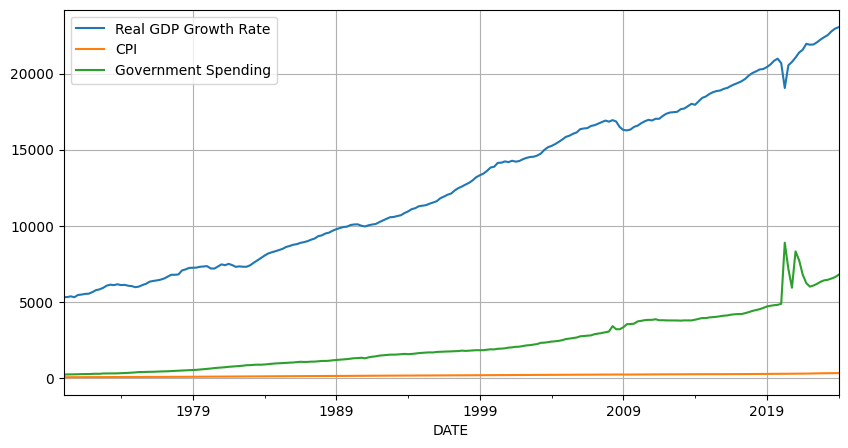

In [9]:
from matplotlib import pyplot as plt

data.plot(figsize=(10, 5))
plt.grid()
plt.show()

## **Table 131. Linearity check: Ensure linear relationship between pairs of the series**

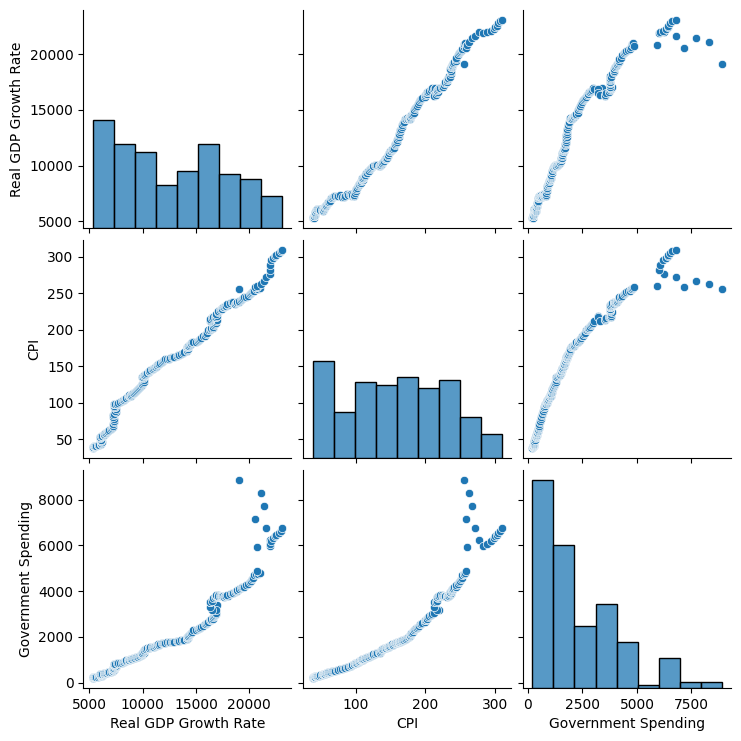

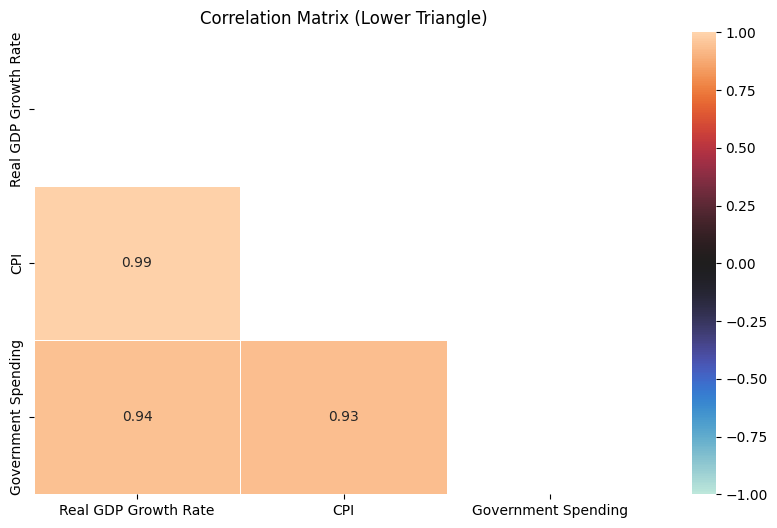

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.pairplot(data)
plt.show()

correlation_matrix = data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.5)

plt.title('Correlation Matrix (Lower Triangle)')
plt.show()

## **Table 132. Data stationarize and ADF test to ensure stationarity**

In [10]:
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

def adf_test(data_df):
    test_stat, p_val = [], []
    cv_1pct, cv_5pct, cv_10pct = [], [], []
    for c in data_df.columns:
        adf_res = adfuller(data_df[c].dropna())
        test_stat.append(adf_res[0])
        p_val.append(adf_res[1])
        cv_1pct.append(adf_res[4]['1%'])
        cv_5pct.append(adf_res[4]['5%'])
        cv_10pct.append(adf_res[4]['10%'])
    adf_res_df = pd.DataFrame({'Test statistic': test_stat,
                               'p-value': p_val,
                               'Critical value - 1%': cv_1pct,
                               'Critical value - 5%': cv_5pct,
                               'Critical value - 10%': cv_10pct},
                             index=data_df.columns).T
    adf_res_df = adf_res_df.round(4)
    table = tabulate(adf_res_df, headers='keys', tablefmt='fancy_grid')
    return table

table_output = adf_test(data)
print(table_output)

╒══════════════════════╤════════════════════════╤═════════╤═══════════════════════╕
│                      │   Real GDP Growth Rate │     CPI │   Government Spending │
╞══════════════════════╪════════════════════════╪═════════╪═══════════════════════╡
│ Test statistic       │                 1.9031 │  1.0328 │                2.5571 │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ p-value              │                 0.9985 │  0.9946 │                0.9991 │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 1%  │                -3.4611 │ -3.4617 │               -3.4633 │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 5%  │                -2.8751 │ -2.8753 │               -2.876  │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 10% │                -2.574  │ -2.5741 │               -2

In [62]:
import numpy as np
data_diff = np.log(data).diff().dropna()
print(data_diff.head())

            Real GDP Growth Rate       CPI  Government Spending
DATE                                                           
1970-04-01              0.001416  0.015707             0.053263
1970-07-01              0.009172  0.010336             0.014702
1970-10-01             -0.010774  0.012772             0.018773
1971-01-01              0.026799  0.012611             0.023950
1971-04-01              0.005394  0.005000             0.041080


In [26]:
def adf_test(data_df):
    test_stat, p_val = [], []
    cv_1pct, cv_5pct, cv_10pct = [], [], []
    for c in data_df.columns:
        adf_res = adfuller(data_df[c].dropna())
        test_stat.append(adf_res[0])
        p_val.append(adf_res[1])
        cv_1pct.append(adf_res[4]['1%'])
        cv_5pct.append(adf_res[4]['5%'])
        cv_10pct.append(adf_res[4]['10%'])
    adf_res_df = pd.DataFrame({'Test statistic': test_stat,
                               'p-value': p_val,
                               'Critical value - 1%': cv_1pct,
                               'Critical value - 5%': cv_5pct,
                               'Critical value - 10%': cv_10pct},
                             index=data_df.columns).T
    adf_res_df = adf_res_df.round(4)
    table = tabulate(adf_res_df, headers='keys', tablefmt='fancy_grid')
    return table

table_output = adf_test(data_diff)
print(table_output)

╒══════════════════════╤════════════════════════╤═════════╤═══════════════════════╕
│                      │   Real GDP Growth Rate │     CPI │   Government Spending │
╞══════════════════════╪════════════════════════╪═════════╪═══════════════════════╡
│ Test statistic       │               -14.7186 │ -3.4626 │               -6.459  │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ p-value              │                 0      │  0.009  │                0      │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 1%  │                -3.4611 │ -3.4614 │               -3.4622 │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 5%  │                -2.8751 │ -2.8752 │               -2.8755 │
├──────────────────────┼────────────────────────┼─────────┼───────────────────────┤
│ Critical value - 10% │                -2.574  │ -2.5741 │               -2

## **Table 133. Information criteria based lag order selection**

In [63]:
from statsmodels.tsa.api import VAR

model = VAR(data_diff)
lag_order = model.select_order(maxlags=12)

print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -24.69      -24.64   1.902e-11      -24.67
1       -25.39      -25.20   9.373e-12      -25.31
2       -25.64      -25.30   7.305e-12      -25.50
3       -25.86     -25.37*   5.862e-12     -25.67*
4      -25.87*      -25.24  5.797e-12*      -25.62
5       -25.83      -25.05   6.058e-12      -25.51
6       -25.82      -24.89   6.152e-12      -25.44
7       -25.80      -24.72   6.271e-12      -25.36
8       -25.81      -24.59   6.202e-12      -25.32
9       -25.76      -24.39   6.527e-12      -25.21
10      -25.73      -24.21   6.773e-12      -25.11
11      -25.71      -24.05   6.884e-12      -25.04
12      -25.64      -23.83   7.433e-12      -24.91
--------------------------------------------------


## **Table 134. Johansen cointegration test**

In [28]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from tabulate import tabulate

johansen_test = coint_johansen(data_diff, det_order=0, k_ar_diff=lag_order.aic)
results_df = pd.DataFrame({
    'Trace Statistic': johansen_test.lr1,
    'Critical Value (90%)': johansen_test.cvt[:, 0],
    'Critical Value (95%)': johansen_test.cvt[:, 1],
    'Critical Value (99%)': johansen_test.cvt[:, 2]
}, index=['r = 0', 'r = 1', 'r = 2'])

print(tabulate(results_df, headers='keys', tablefmt='fancy_grid'))

╒═══════╤═══════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│       │   Trace Statistic │   Critical Value (90%) │   Critical Value (95%) │   Critical Value (99%) │
╞═══════╪═══════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ r = 0 │           87.2715 │                27.0669 │                29.7961 │                35.4628 │
├───────┼───────────────────┼────────────────────────┼────────────────────────┼────────────────────────┤
│ r = 1 │           42.4414 │                13.4294 │                15.4943 │                19.9349 │
├───────┼───────────────────┼────────────────────────┼────────────────────────┼────────────────────────┤
│ r = 2 │            7.0491 │                 2.7055 │                 3.8415 │                 6.6349 │
╘═══════╧═══════════════════╧════════════════════════╧════════════════════════╧════════════════════════╛


## **Table 135. VAR model**

In [64]:
model = VAR(data_diff).fit(lag_order.aic)
print(model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 20, Dec, 2024
Time:                     04:57:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.2542
Nobs:                     212.000    HQIC:                  -25.6221
Log likelihood:           1878.95    FPE:                5.81149e-12
AIC:                     -25.8716    Det(Omega_mle):     4.86125e-12
--------------------------------------------------------------------
Results for equation Real GDP Growth Rate
                             coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------
const                           0.002937         0.001687            1.740           0.082
L1.Real GDP Growth Rate         0.334296         0.084302            3.965           0.000
L1.CP

In [30]:
model.resid.cov()

,Real GDP Growth Rate,CPI,Government Spending
Real GDP Growth Rate,0.000087,0.000007,-0.000244
CPI,0.000007,0.000033,-0.000038
Government Spending,-0.000244,-0.000038,0.002130


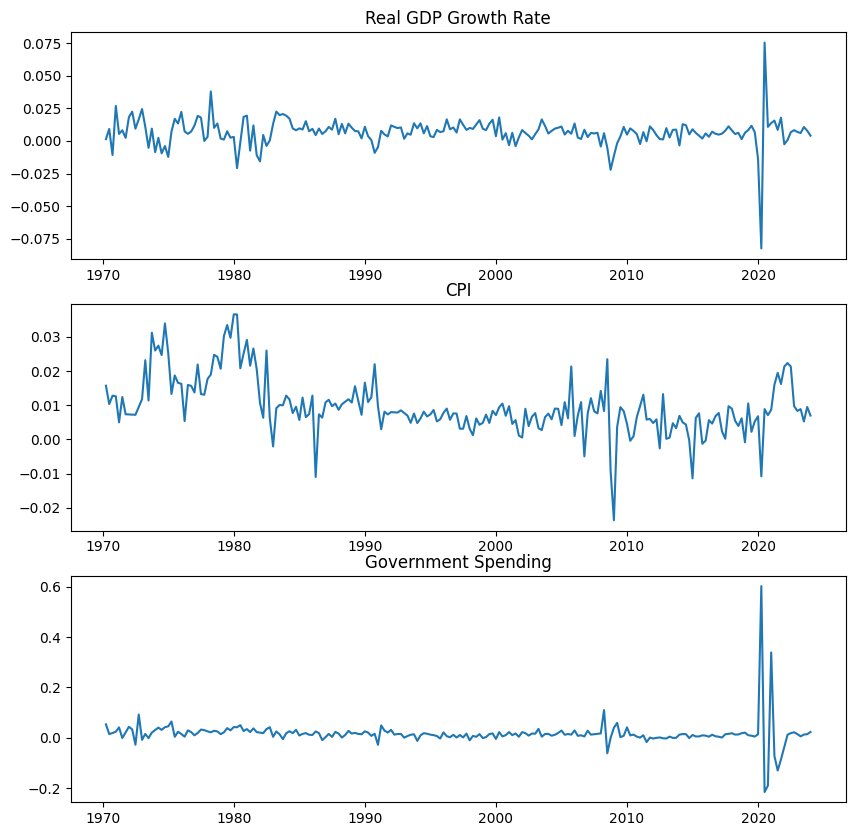

In [31]:
model.plot()
plt.show()

## **Table 136. Residuals analysis**

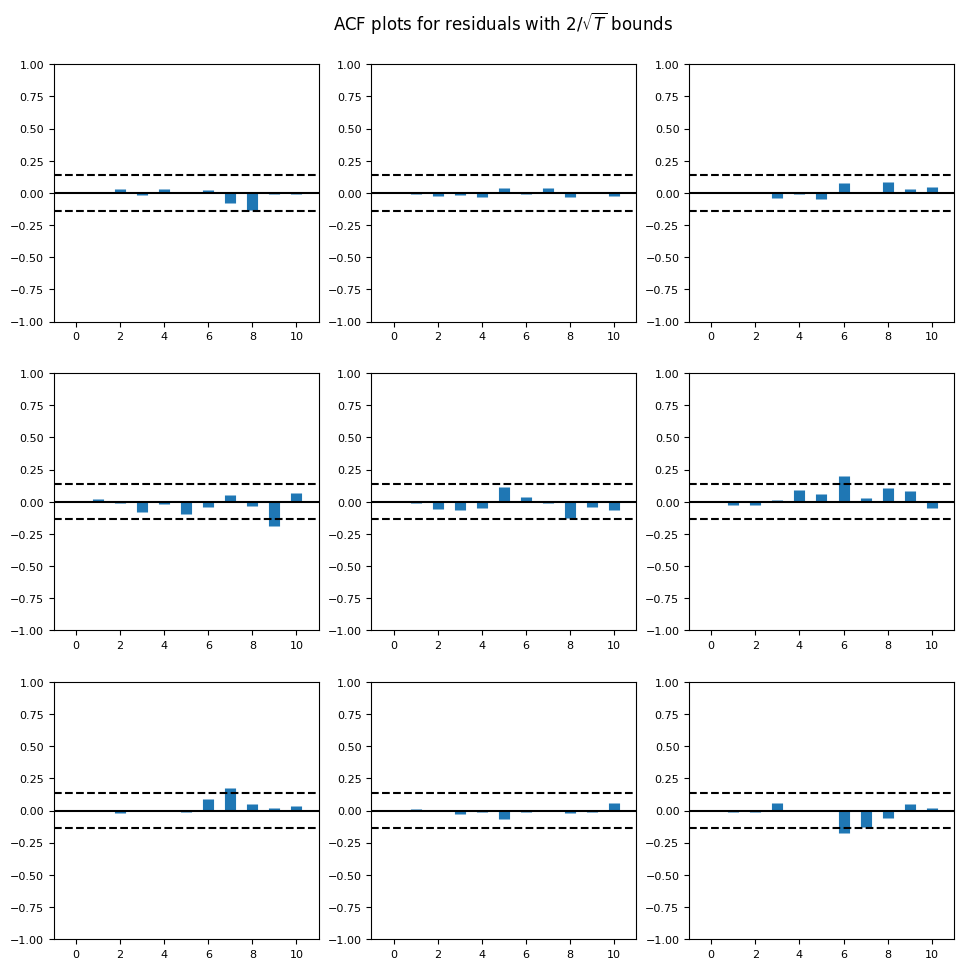

In [32]:
model.plot_acorr()
plt.show()

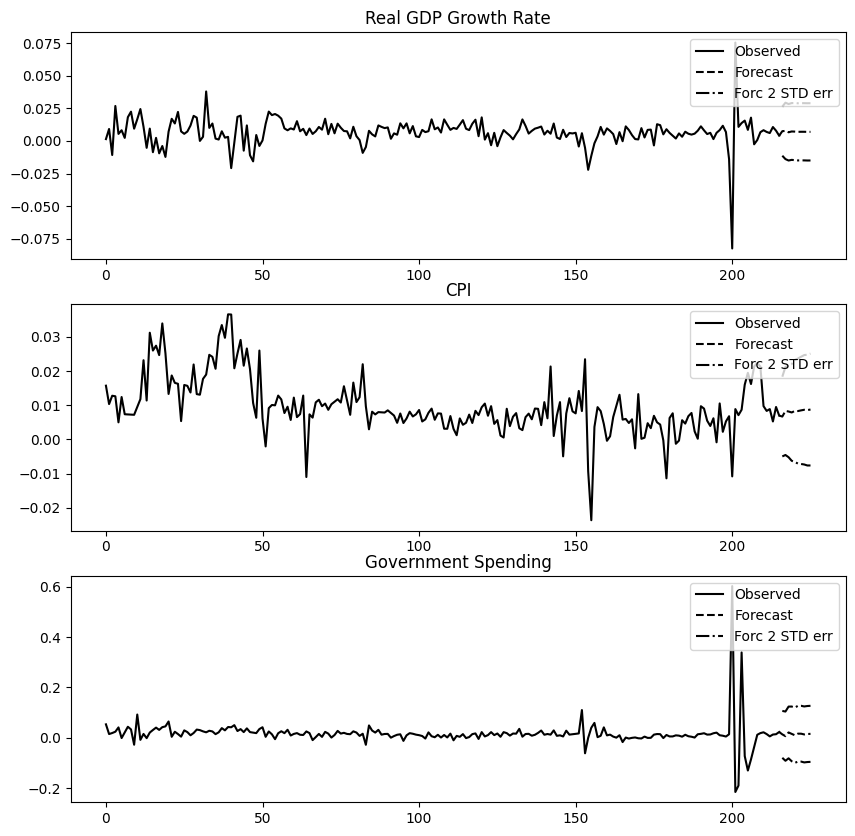

In [ ]:
model.plot_forecast(10)
plt.show()

## **Table 138. Granger causality analysis**

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

p = lag_order
def granger_causation_matrix(data, variables, p, test = 'ssr_chi2test', verbose=False):

    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(train[[r, c]], p)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(p)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

granger_causation_matrix(data, data.columns, p)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=201, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=5.6374  , p=0.0185  , df_denom=201, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=199, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=0.0000  , p=1.0000  , df=2
parameter F test:         F=3.3223  , p=0.0381  , df_denom=199, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=197, df_num=3
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=3.2759  , p=0.0221  , df_denom=197, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.0000  , p=1.0000  

,Real GDP Growth Rate_x,CPI_x,Government Spending_x
Real GDP Growth Rate_y,1.0000,0.0022,0.0000
CPI_y,0.0571,1.0000,0.0653
Government Spending_y,0.0000,0.1134,1.0000


## **Table 139. IRFs - Unit shocks to the non-orthogonalized residuals plot**

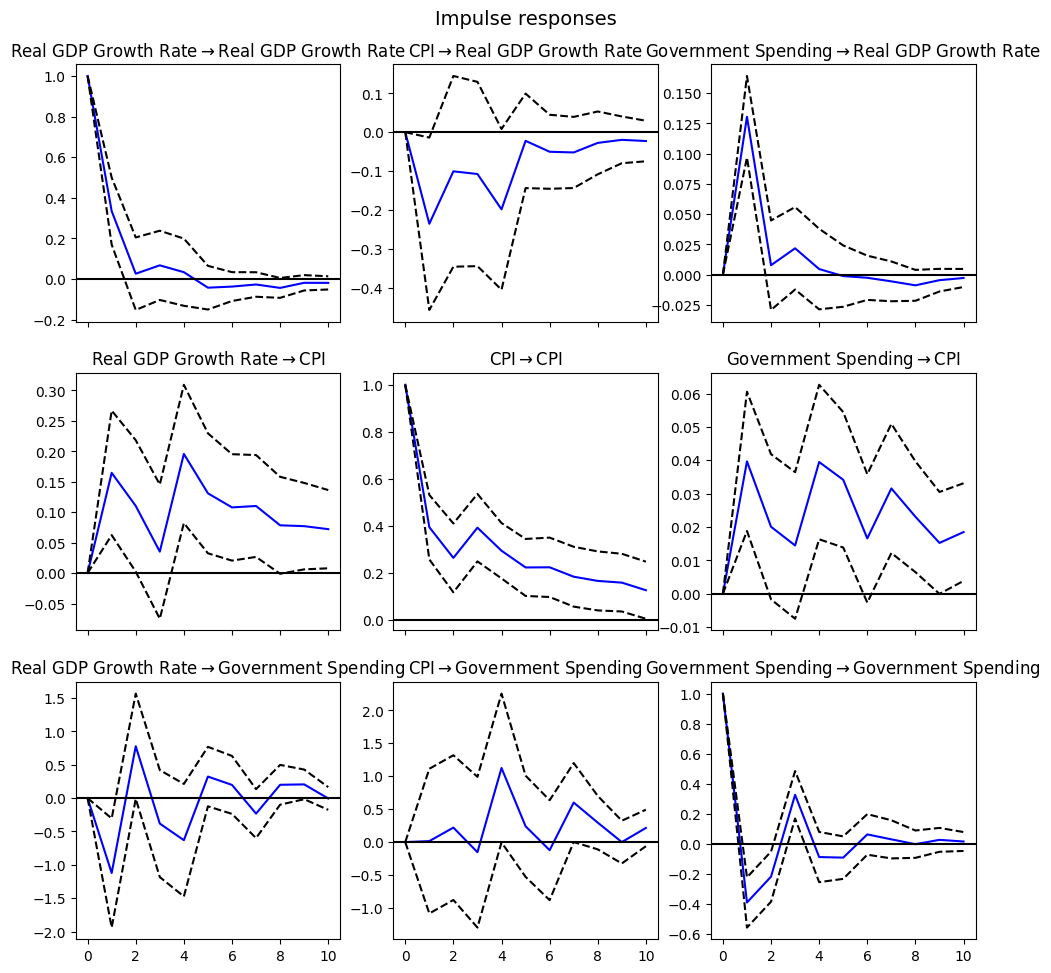

In [ ]:
irf = model.irf(10)
irf.plot()
plt.show()

## **Table 140. Unit shocks to the orthogonalized residuals**

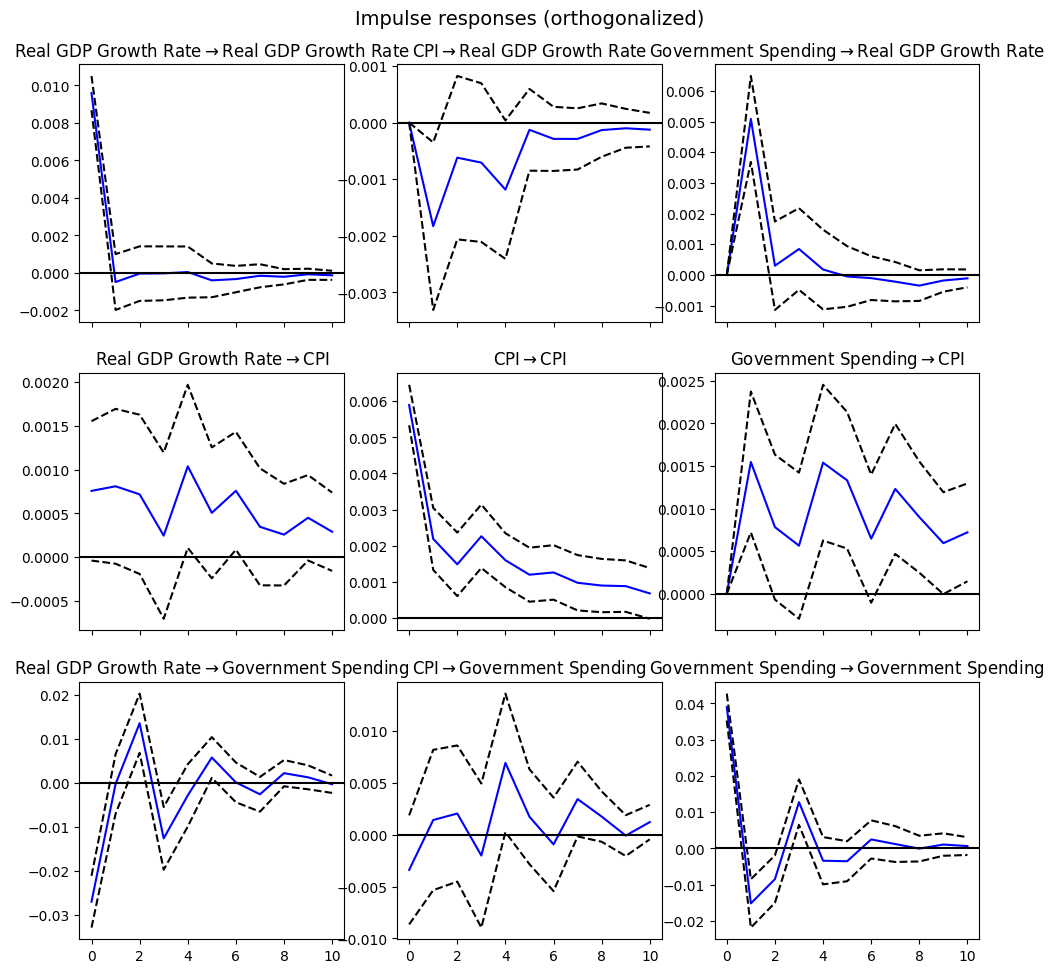

In [ ]:
irf.plot(orth = True)
plt.show()

## **Table 141. FEVD estimation**

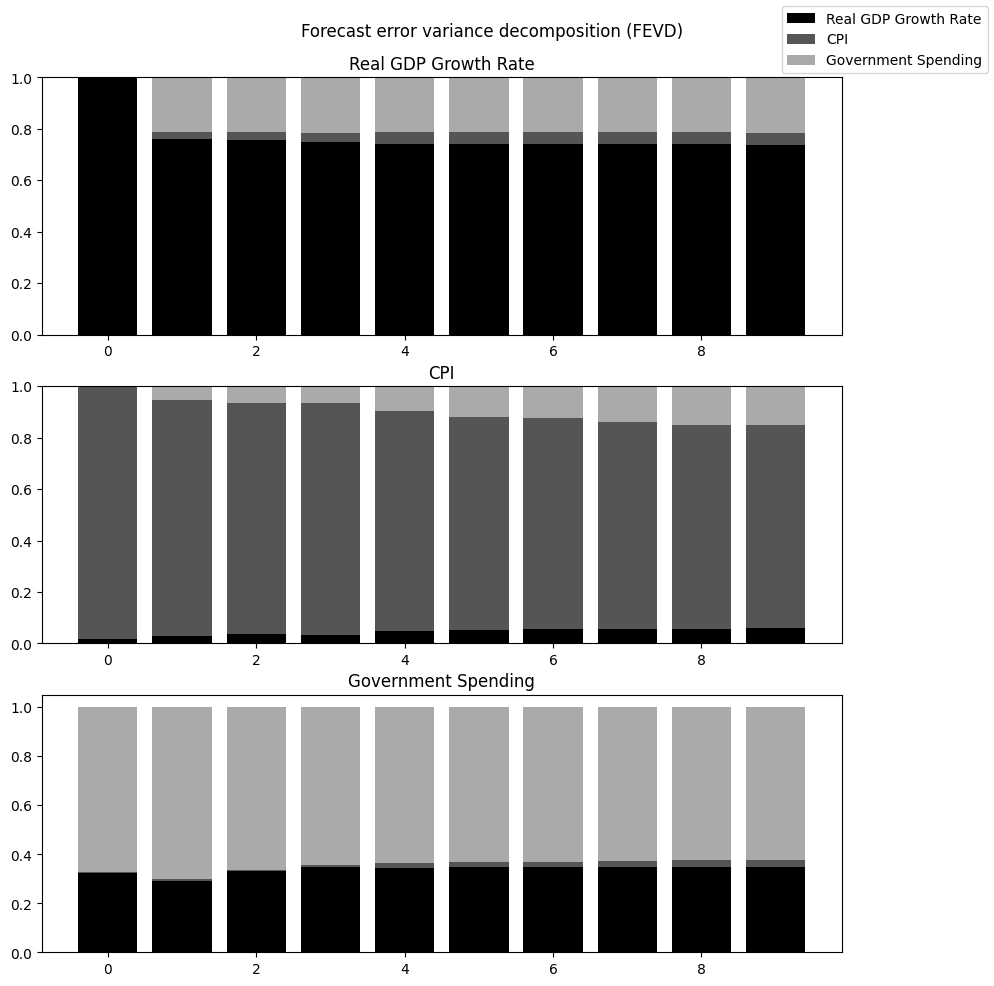

In [58]:
fevd = model.fevd(10)
fevd.plot()
plt.show()

In [59]:
fevd.summary()

FEVD for Real GDP Growth Rate
     Real GDP Growth Rate       CPI  Government Spending
0                1.000000  0.000000             0.000000
1                0.759553  0.027591             0.212856
2                0.756597  0.030633             0.212770
3                0.749131  0.034393             0.216476
4                0.740508  0.045260             0.214231
5                0.740724  0.045326             0.213950
6                0.740392  0.045915             0.213693
7                0.739664  0.046522             0.213814
8                0.738937  0.046594             0.214469
9                0.738695  0.046656             0.214648

FEVD for CPI
     Real GDP Growth Rate       CPI  Government Spending
0                0.016200  0.983800             0.000000
1                0.028424  0.916090             0.055487
2                0.037447  0.897866             0.064687
3                0.034648  0.901378             0.063975
4                0.049615  0.852131         

In [ ]:
data.columns

Index(['Real GDP Growth Rate', 'CPI', 'Government Spending'], dtype='object')

## **Table 142. FEVD with reverse order variables**

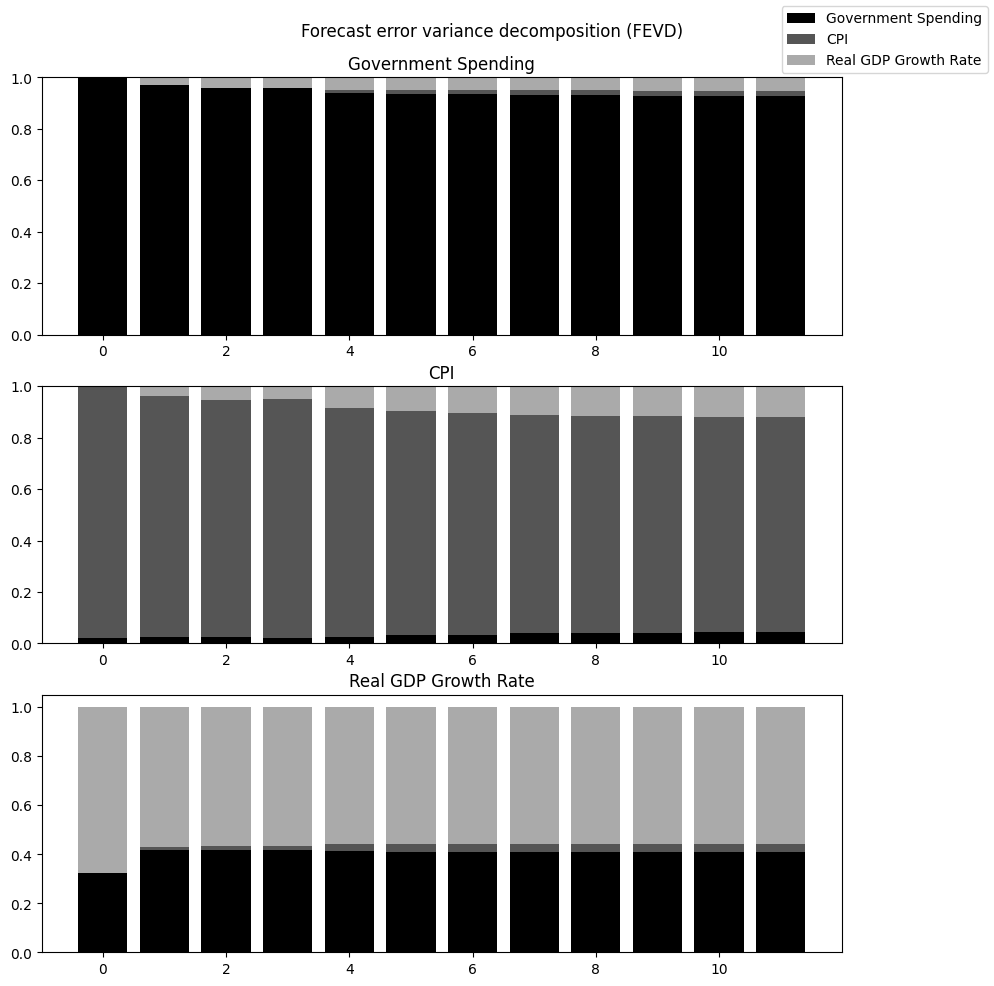

In [ ]:
model = VAR(data[['Government Spending', 'CPI', 'Real GDP Growth Rate']]).fit(maxlags=lag_order)
fevd = model.fevd(12)
fevd.plot()
plt.show()

## **Table 143. Forecast and inverse logdiff() back to the original shape**

In [68]:
import numpy as np

forecast_values = model.forecast(data_diff.values[-lag_order.aic:], 5)
last_observed_values = data.values[-1]
inversed_forecast = np.zeros_like(forecast_values)

for i in range(forecast_values.shape[1]):
    cumulative_sum = np.cumsum(forecast_values[:, i])
    inversed_log_values = np.log(last_observed_values[i]) + cumulative_sum
    inversed_forecast[:, i] = np.exp(inversed_log_values)

forecast_df = pd.DataFrame(inversed_forecast, columns=data.columns)
print(forecast_df)

   Real GDP Growth Rate         CPI  Government Spending
0          23226.630403  311.761936          6864.475429
1          23406.205004  314.369125          6908.148689
2          23562.199576  316.945883          7055.044223
3          23733.814596  319.454413          7164.108313
4          23904.154892  322.126708          7235.570880


## **Table 144. Error Correction Model**

In [71]:
import pandas as pd
import pandas_datareader.data as web
import datetime

start = datetime.datetime(1990, 1, 1)
end = datetime.datetime(2024, 1, 1)

def get_data(symbol, start, end):
    data = web.DataReader(symbol, 'fred', start, end)
    return data.resample('QE').mean()

cpi = get_data('CPIAUCNS', start, end) # consumer price index
pce = get_data('PCE', start, end) # personal consumption expenditure
dpi= get_data('DPI', start, end) # disposable personal income


data = pd.concat([cpi, pce, dpi], axis=1)
data.columns = ['CPI', 'PCE', 'DPI']
data = data.dropna()
print(data.head())

                   CPI          PCE       DPI
DATE                                         
1990-03-31  128.033333  3737.933333  4232.899
1990-06-30  129.333333  3783.433333  4302.906
1990-09-30  131.566667  3846.700000  4358.183
1990-12-31  133.700000  3867.933333  4380.538
1991-03-31  134.800000  3873.566667  4416.999


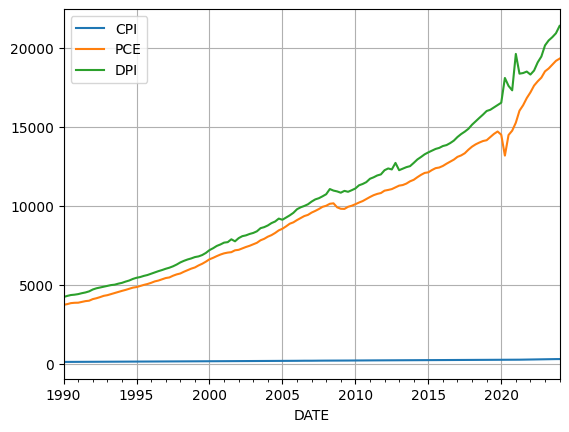

In [72]:
data.plot()
plt.grid()
plt.show()

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 137 entries, 1990-03-31 to 2024-03-31
Freq: QE-DEC
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CPI     137 non-null    float64
 1   PCE     137 non-null    float64
 2   DPI     137 non-null    float64
dtypes: float64(3)
memory usage: 4.3 KB


## **Table 145. Series plots to check correlation**

          CPI       PCE       DPI
CPI  1.000000  0.995652  0.990807
PCE  0.995652  1.000000  0.994849
DPI  0.990807  0.994849  1.000000


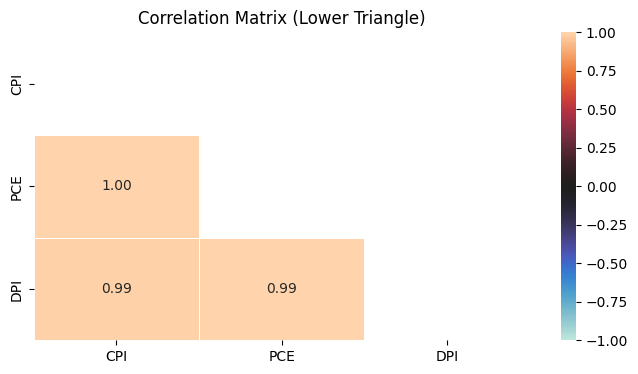

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

correlation_matrix = data.corr(method='pearson')
print(correlation_matrix)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Correlation Matrix (Lower Triangle)')
plt.show()

## **Table 146. Stationarity check**

In [75]:
from statsmodels.tsa.stattools import adfuller

def adf_test(data_df):
    test_stat, p_val = [], []
    cv_1pct, cv_5pct, cv_10pct = [], [], []
    for c in data_df.columns:
        adf_res = adfuller(data_df[c].dropna())
        test_stat.append(adf_res[0])
        p_val.append(adf_res[1])
        cv_1pct.append(adf_res[4]['1%'])
        cv_5pct.append(adf_res[4]['5%'])
        cv_10pct.append(adf_res[4]['10%'])
    adf_res_df = pd.DataFrame({'Test statistic': test_stat,
                               'p-value': p_val,
                               'Critical value - 1%': cv_1pct,
                               'Critical value - 5%': cv_5pct,
                               'Critical value - 10%': cv_10pct},
                             index=data_df.columns).T
    adf_res_df = adf_res_df.round(4)
    return adf_res_df

adf_results = adf_test(data)
table = tabulate(adf_results, headers='keys', tablefmt='fancy_grid')
print(table)

╒══════════════════════╤═════════╤═════════╤═════════╕
│                      │     CPI │     PCE │     DPI │
╞══════════════════════╪═════════╪═════════╪═════════╡
│ Test statistic       │  1.584  │  3.1915 │  4.8606 │
├──────────────────────┼─────────┼─────────┼─────────┤
│ p-value              │  0.9978 │  1      │  1      │
├──────────────────────┼─────────┼─────────┼─────────┤
│ Critical value - 1%  │ -3.4838 │ -3.4794 │ -3.4821 │
├──────────────────────┼─────────┼─────────┼─────────┤
│ Critical value - 5%  │ -2.885  │ -2.883  │ -2.8842 │
├──────────────────────┼─────────┼─────────┼─────────┤
│ Critical value - 10% │ -2.5793 │ -2.5782 │ -2.5789 │
╘══════════════════════╧═════════╧═════════╧═════════╛


## **Table 147. Autocorrelation plot**

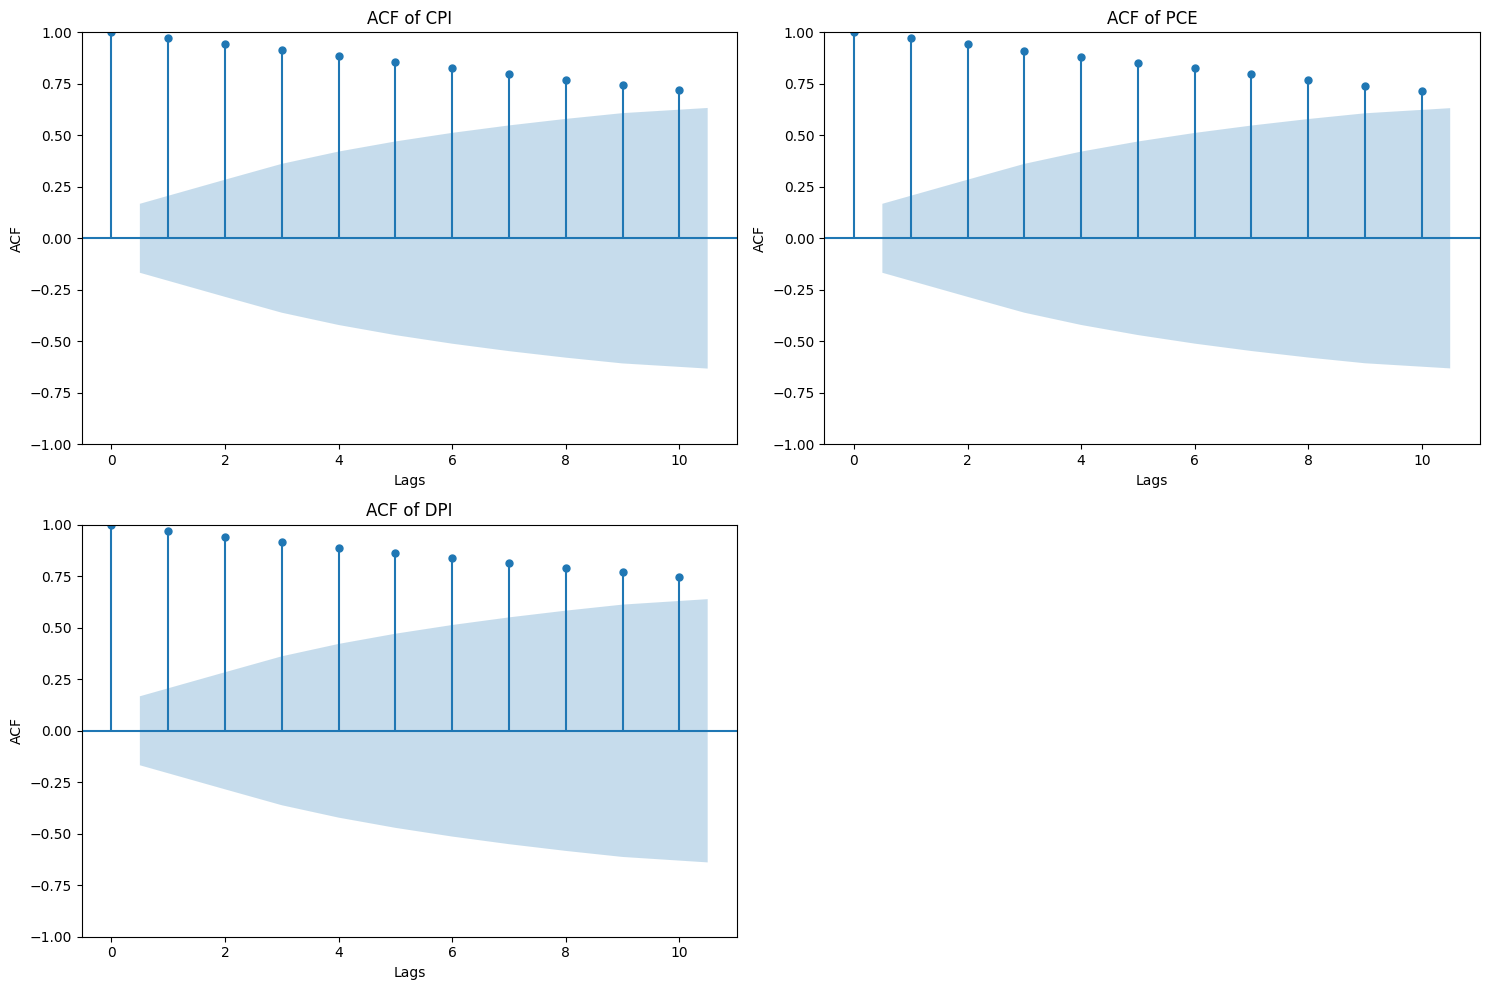

In [76]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

num_plots = len(data.columns)
num_rows = (num_plots + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5))

axes = axes.flatten()

for idx, column in enumerate(data.columns):
    plot_acf(data[column], lags=10, ax=axes[idx])
    axes[idx].set_title(f'ACF of {column}')
    axes[idx].set_xlabel('Lags')
    axes[idx].set_ylabel('ACF')
    axes[idx].tick_params(axis='both', which='major')

for ax in axes[num_plots:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## **Table 148. Cointegration checks**

In [77]:
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from tabulate import tabulate

def test_cointegration(series1, series2):
    score, p_value, _ = coint(series1, series2)
    print(f'Cointegration test score: {score}, p-value: {p_value}')

for i in range(len(data.columns)):
    for j in range(i+1, len(data.columns)):
        test_cointegration(data.iloc[:, i], data.iloc[:, j])

johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

results_df = pd.DataFrame({
    'Trace Statistic': johansen_test.lr1,
    'Critical Value (90%)': johansen_test.cvt[:, 0],
    'Critical Value (95%)': johansen_test.cvt[:, 1],
    'Critical Value (99%)': johansen_test.cvt[:, 2]
}, index=['r = 0', 'r = 1', 'r = 2'])  # Adjust index as needed

print(tabulate(results_df, headers='keys', tablefmt='fancy_grid'))

Cointegration test score: -1.522815508125729, p-value: 0.7523397070726376
Cointegration test score: -2.1124450905194805, p-value: 0.4698635574421082
Cointegration test score: -4.59300207081588, p-value: 0.0008578319888068618
╒═══════╤═══════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│       │   Trace Statistic │   Critical Value (90%) │   Critical Value (95%) │   Critical Value (99%) │
╞═══════╪═══════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ r = 0 │          72.2629  │                27.0669 │                29.7961 │                35.4628 │
├───────┼───────────────────┼────────────────────────┼────────────────────────┼────────────────────────┤
│ r = 1 │          32.5624  │                13.4294 │                15.4943 │                19.9349 │
├───────┼───────────────────┼────────────────────────┼────────────────────────┼────────────────────────┤
│ r = 2 │           9.15057 │           

## **Table 149. Cointegration vectors**

In [78]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

results_df = pd.DataFrame({
    'Eigenvalues': johansen_test.eig,
    'Cointegration Vector 1': johansen_test.evec[:, 0],
    'Cointegration Vector 2': johansen_test.evec[:, 1],
    'Cointegration Vector 3': johansen_test.evec[:, 2] })

print(tabulate(results_df, headers='keys', tablefmt='fancy_grid'))

╒════╤═══════════════╤══════════════════════════╤══════════════════════════╤══════════════════════════╕
│    │   Eigenvalues │   Cointegration Vector 1 │   Cointegration Vector 2 │   Cointegration Vector 3 │
╞════╪═══════════════╪══════════════════════════╪══════════════════════════╪══════════════════════════╡
│  0 │     0.254781  │              0.145874    │               0.0990585  │              0.186951    │
├────┼───────────────┼──────────────────────────┼──────────────────────────┼──────────────────────────┤
│  1 │     0.159217  │             -0.00193226  │              -0.00347324 │             -0.000798268 │
├────┼───────────────┼──────────────────────────┼──────────────────────────┼──────────────────────────┤
│  2 │     0.0655358 │              2.49454e-05 │               0.00218374 │             -0.00109478  │
╘════╧═══════════════╧══════════════════════════╧══════════════════════════╧══════════════════════════╛


## **Table 150. Lag-order selection**

In [79]:
from statsmodels.tsa.vector_ar.vecm import VECM, select_order

data.index = pd.to_datetime(data.index)
data = data.asfreq('QE')
lag_order = select_order(data=data, maxlags=10)
print(lag_order.summary())
print(lag_order)

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        22.09       22.36   3.922e+09       22.20
1        21.90       22.37   3.248e+09       22.09
2        21.39       22.07   1.958e+09       21.67
3        20.48      21.36*   7.877e+08       20.84
4        20.38       21.46   7.094e+08      20.81*
5        20.36       21.64   6.992e+08       20.88
6        20.37       21.85   7.066e+08       20.97
7        20.28       21.97   6.507e+08       20.96
8       20.23*       22.12  6.235e+08*       21.00
9        20.32       22.41   6.857e+08       21.17
10       20.25       22.54   6.461e+08       21.18
--------------------------------------------------
<statsmodels.tsa.vector_ar.var_model.LagOrderResults object. Selected orders are: AIC -> 8, BIC -> 3, FPE -> 8, HQIC ->  4>


## **Table 151. Johansen cointegration rank test**

In [80]:
from statsmodels.tsa.vector_ar.vecm import *

rank_test = select_coint_rank(data, det_order = 0, k_ar_diff = lag_order.aic, method="trace", signif=0.05)
print(rank_test.rank)
print(rank_test.summary())

3
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   3          45.36          29.80
  1   3          22.16          15.49
  2   3          4.596          3.841
-------------------------------------


In [81]:
rank2 = select_coint_rank(data, det_order = 0, k_ar_diff = lag_order.aic, method = 'maxeig', signif=0.05)
print(rank2.summary())


Johansen cointegration test using maximum eigenvalue test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   1          23.19          21.13
  1   2          17.57          14.26
  2   3          4.596          3.841
-------------------------------------


## **Table 152. VECM model fitting**

In [82]:
model = VECM(data, k_ar_diff = lag_order.aic, coint_rank=rank_test.rank).fit()
print(model.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation CPI
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.CPI         0.1906      0.099      1.919      0.055      -0.004       0.385
L1.PCE         0.0034      0.001      4.367      0.000       0.002       0.005
L1.DPI         0.0027      0.001      2.969      0.003       0.001       0.004
L2.CPI        -0.5934      0.099     -6.006      0.000      -0.787      -0.400
L2.PCE         0.0040      0.001      4.869      0.000       0.002       0.006
L2.DPI         0.0003      0.001      0.306      0.760      -0.001       0.002
L3.CPI         0.1799      0.113      1.597      0.110      -0.041       0.401
L3.PCE         0.0010      0.001      1.000      0.317      -0.001       0.003
L3.DPI      9.371e-05      0.001      0.120      0.904      -0.001       0.002
L4.CPI        -0.0995      0.111     -0.895     

In [92]:
print('beta')
print(model.beta)
print('__________________________')
print('alpha')
print(model.alpha)

beta
[[ 1.00000000e+00  2.93048144e-15  2.06368193e-15]
 [ 1.55895685e-16  1.00000000e+00  1.46382161e-15]
 [-8.39083727e-17  5.10748131e-16  1.00000000e+00]]
__________________________
alpha
[[ 0.00241328 -0.00087055  0.00071   ]
 [ 0.57364815 -0.26414727  0.2278808 ]
 [-0.07848754 -0.02589927  0.04074233]]


## **Table 153. Ljung-Box test of residuals**

In [86]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid.flatten()
ljungbox_test = acorr_ljungbox(residuals, return_df=True)
print(ljungbox_test)

      lb_stat     lb_pvalue
1   36.189241  1.790564e-09
2   36.220603  1.363943e-08
3   36.226275  6.707236e-08
4   36.231484  2.593130e-07
5   36.262009  8.418075e-07
6   36.268864  2.444004e-06
7   36.322803  6.300065e-06
8   36.402222  1.481928e-05
9   36.572547  3.136496e-05
10  36.581451  6.684548e-05


## **Impulse response analysis**

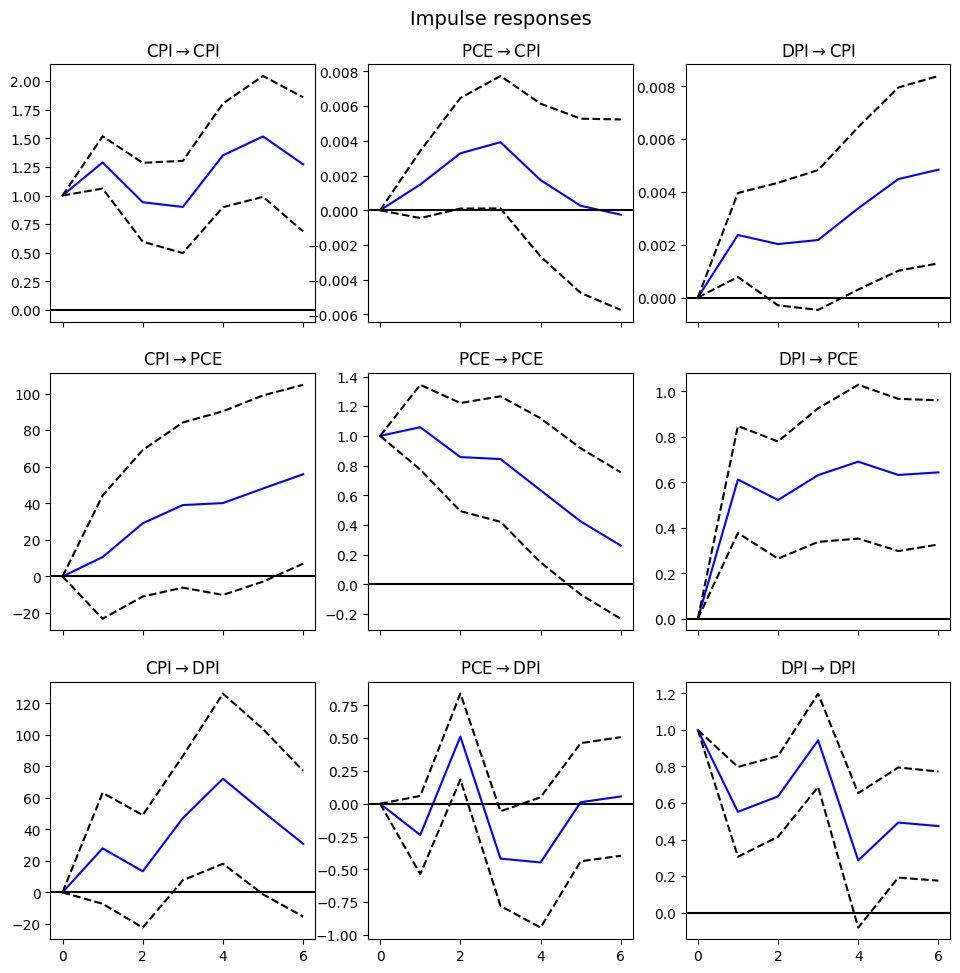

In [ ]:
from statsmodels.tsa.vector_ar.irf import IRAnalysis

irf = model.irf(6)
irf.plot(orth=False)
plt.show()

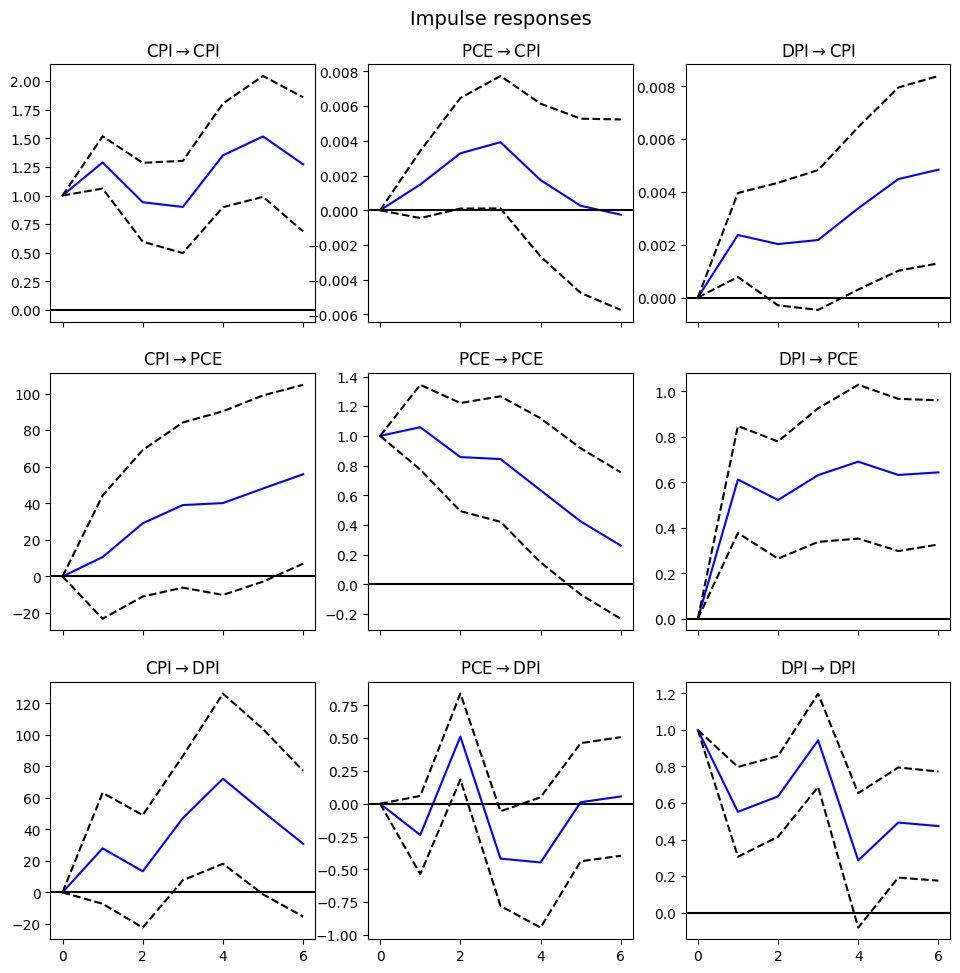

In [ ]:
irf.plot(orth = False)
plt.show()